In [1]:
# ============================================
# QC001 - El qubit más hermoso del mundo
# QuantumCanvas - Video 001
# Pipeline: Jupyter → Houdini → OBS → YouTube
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import qutip as qt

print("✅ Libraries loaded!")
print(f"QuTiP version: {qt.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded!
QuTiP version: 5.2.3
NumPy version: 2.4.2


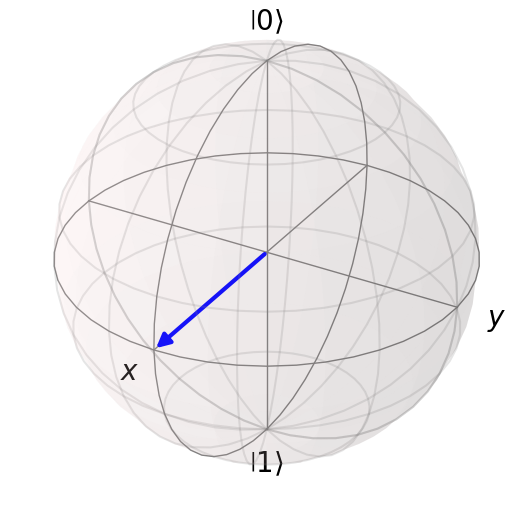

Estado: |+> = (|0> + |1>) / sqrt(2)
Pureza: 1.0000


In [2]:
# ============================================
# Esfera de Bloch - Visualización básica
# ============================================

# Crear estado de superposición |+>
psi = (qt.basis(2,0) + qt.basis(2,1)).unit()

# Crear esfera de Bloch
b = qt.Bloch()

# Agregar el estado
b.add_states(psi)

# Personalizar apariencia
b.sphere_alpha = 0.1
b.frame_color  = 'gray'
b.point_color  = ['red']
b.vector_color = ['blue']

# Mostrar
b.show()

print(f"Estado: |+> = (|0> + |1>) / sqrt(2)")
print(f"Pureza: {(psi * psi.dag()).tr():.4f}")

In [3]:
# ============================================
# QC001 - Exportar datos para Houdini
# ============================================
import pandas as pd
import os

# Crear directorio de exports si no existe
export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
os.makedirs(export_path, exist_ok=True)

# Generar estados del qubit en diferentes angulos
# Theta = angulo polar (0 a pi)
# Phi   = angulo azimutal (0 a 2pi)
frames = 120  # 120 frames = 4 segundos a 30fps

rows = []
for frame in range(frames):
    # Angulo que rota en el tiempo
    phi   = (frame / frames) * 2 * np.pi
    theta = np.pi / 2  # ecuador de la esfera

    # Coordenadas cartesianas en esfera de Bloch
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    # Estado cuantico
    psi = np.cos(theta/2) * qt.basis(2,0) + \
          np.exp(1j*phi) * np.sin(theta/2) * qt.basis(2,1)

    # Pureza del estado
    rho    = psi * psi.dag()
    purity = (rho * rho).tr().real

    rows.append({
        "frame":        frame + 1,
        "x":            x,
        "y":            y,
        "z":            z,
        "theta":        theta,
        "phi":          phi,
        "purity":       purity,
        "houdini_frame": frame + 1
    })

# Exportar CSV
df = pd.DataFrame(rows)
output_file = export_path + "QC001_bloch_data.csv"
df.to_csv(output_file, index=False, float_format="%.6f")

print(f"✅ Exportado: {output_file}")
print(f"   Frames: {len(df)}")
print(f"   Columnas: {list(df.columns)}")
print(f"\n{df.head()}")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_bloch_data.csv
   Frames: 120
   Columnas: ['frame', 'x', 'y', 'z', 'theta', 'phi', 'purity', 'houdini_frame']

   frame         x         y             z     theta      phi  purity  \
0      1  1.000000  0.000000  6.123234e-17  1.570796  0.00000     1.0   
1      2  0.998630  0.052336  6.123234e-17  1.570796  0.05236     1.0   
2      3  0.994522  0.104528  6.123234e-17  1.570796  0.10472     1.0   
3      4  0.987688  0.156434  6.123234e-17  1.570796  0.15708     1.0   
4      5  0.978148  0.207912  6.123234e-17  1.570796  0.20944     1.0   

   houdini_frame  
0              1  
1              2  
2              3  
3              4  
4              5  


In [1]:
# ============================================
# QC001 - Animacion 3: Transicion |0> a |1>
# ============================================
import numpy as np
import pandas as pd
import os

export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
frames = 120

rows = []
for frame in range(frames):
    # t va de 0 a 1 durante la animacion
    t = frame / (frames - 1)

    # Theta va de 0 (|0>) a pi (|1>)
    # Usando funcion suave (ease in/out)
    theta = np.pi * (3*t**2 - 2*t**3)  # smoothstep

    # Phi fijo en 0 para esta transicion
    phi = 0.0

    # Coordenadas en esfera de Bloch
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    rows.append({
        "frame":         frame + 1,
        "houdini_frame": frame + 1,
        "x":             x,
        "y":             y,
        "z":             z,
        "theta":         theta,
        "phi":           phi,
        "purity":        1.0
    })

df = pd.DataFrame(rows)
output = export_path + "QC001_transition_0_to_1.csv"
df.to_csv(output, index=False, float_format="%.6f")

print(f"✅ Exportado: {output}")
print(f"   Frames: {len(df)}")
print(f"   Theta: 0 → {np.pi:.4f} (de |0> a |1>)")
print(f"\n{df.head()}")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_transition_0_to_1.csv
   Frames: 120
   Theta: 0 → 3.1416 (de |0> a |1>)

   frame  houdini_frame         x    y         z     theta  phi  purity
0      1              1  0.000000  0.0  1.000000  0.000000  0.0     1.0
1      2              2  0.000662  0.0  1.000000  0.000662  0.0     1.0
2      3              3  0.002632  0.0  0.999997  0.002632  0.0     1.0
3      4              4  0.005889  0.0  0.999983  0.005889  0.0     1.0
4      5              5  0.010410  0.0  0.999946  0.010410  0.0     1.0


In [2]:
# ============================================
# QC001 - Animacion 4: Decoherencia visual
# Qubit colapsando hacia |0>
# ============================================
import numpy as np
import pandas as pd

export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
frames = 120

rows = []
for frame in range(frames):
    t = frame / (frames - 1)

    # Decoherencia: theta va de pi/2 (ecuador) a 0 (|0>)
    # Exponencial decayendo - fisica real!
    decay = np.exp(-4 * t)  # tasa de decoherencia

    # Theta colapsa al polo norte
    theta = (np.pi / 2) * decay

    # Phi sigue girando pero se frena
    phi = 2 * np.pi * t * (1 - t)

    # Coordenadas
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    # Pureza decrece durante decoherencia
    purity = decay

    rows.append({
        "frame":         frame + 1,
        "houdini_frame": frame + 1,
        "x":             x,
        "y":             y,
        "z":             z,
        "theta":         theta,
        "phi":           phi,
        "purity":        purity
    })

df = pd.DataFrame(rows)
output = export_path + "QC001_decoherence.csv"
df.to_csv(output, index=False, float_format="%.6f")

print(f"✅ Exportado: {output}")
print(f"   Frames: {len(df)}")
print(f"\nInicio  → theta={df.iloc[0].theta:.3f}  z={df.iloc[0].z:.3f}  purity={df.iloc[0].purity:.3f}")
print(f"Mitad   → theta={df.iloc[59].theta:.3f}  z={df.iloc[59].z:.3f}  purity={df.iloc[59].purity:.3f}")
print(f"Final   → theta={df.iloc[-1].theta:.3f}  z={df.iloc[-1].z:.3f}  purity={df.iloc[-1].purity:.3f}")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_decoherence.csv
   Frames: 120

Inicio  → theta=1.571  z=0.000  purity=1.000
Mitad   → theta=0.216  z=0.977  purity=0.138
Final   → theta=0.029  z=1.000  purity=0.018


In [4]:
# ============================================
# QC001 - Animacion 5: Latitud variable V2
# Mas dramatico - sube hasta |0> y baja hasta |1>
# ============================================
import numpy as np
import pandas as pd

export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
frames = 120

rows = []
for frame in range(frames):
    t = frame / (frames - 1)

    # Phi gira 2 vueltas completas
    phi = 2 * np.pi * 2 * t

    # Theta oscila dramaticamente
    # 0.2 = cerca de |0> arriba
    # 2.9 = cerca de |1> abajo
    theta = np.pi/2 + (np.pi/2 * 0.95) * np.sin(2 * np.pi * 1.5 * t)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    rows.append({
        "frame":         frame + 1,
        "houdini_frame": frame + 1,
        "x": x, "y": y, "z": z,
        "theta": theta, "phi": phi,
        "purity": 1.0
    })

df = pd.DataFrame(rows)
output = export_path + "QC001_latitude_wave.csv"
df.to_csv(output, index=False, float_format="%.6f")

print(f"✅ Exportado: {output}")
print(f"\nFrame 1   → z={df.iloc[0].z:.3f}")
print(f"Frame 20  → z={df.iloc[19].z:.3f}")
print(f"Frame 40  → z={df.iloc[39].z:.3f}")
print(f"Frame 60  → z={df.iloc[59].z:.3f}")
print(f"Frame 80  → z={df.iloc[79].z:.3f}")
print(f"Frame 120 → z={df.iloc[-1].z:.3f}")
print(f"\nZ min: {df.z.min():.3f}  Z max: {df.z.max():.3f}")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_latitude_wave.csv

Frame 1   → z=0.000
Frame 20  → z=-0.997
Frame 40  → z=-0.079
Frame 60  → z=0.997
Frame 80  → z=0.039
Frame 120 → z=-0.000

Z min: -0.997  Z max: 0.997


In [5]:
# ============================================
# QC001 - Animacion 6: Pulso Tunneling
# Qubit aparece y desaparece - efecto tunel
# ============================================
import numpy as np
import pandas as pd

export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
frames = 120

rows = []
for frame in range(frames):
    t = frame / (frames - 1)

    # Phi gira constantemente
    phi = 2 * np.pi * 2 * t

    # Theta en el ecuador
    theta = np.pi / 2

    # Pulso: aparece y desaparece 3 veces
    # Gaussian pulses
    pulses = 3
    purity = 0.0
    for i in range(pulses):
        center = (i + 0.5) / pulses
        width  = 0.08
        purity += np.exp(-((t - center)**2) / (2 * width**2))

    purity = np.clip(purity, 0.0, 1.0)

    # Escala la posicion con la pureza
    # Cuando purity=0 el qubit desaparece al origen
    scale = purity

    x = scale * np.sin(theta) * np.cos(phi)
    y = scale * np.sin(theta) * np.sin(phi)
    z = scale * np.cos(theta)

    rows.append({
        "frame":         frame + 1,
        "houdini_frame": frame + 1,
        "x": x, "y": y, "z": z,
        "theta": theta, "phi": phi,
        "purity": purity,
        "scale": scale
    })

df = pd.DataFrame(rows)
output = export_path + "QC001_tunneling.csv"
df.to_csv(output, index=False, float_format="%.6f")

print(f"✅ Exportado: {output}")
print(f"\nPulsos en frames:")
for i, row in df.iterrows():
    if row.purity > 0.95:
        print(f"  Frame {int(row.frame):3d} → purity={row.purity:.3f} PULSO MAXIMO")
print(f"\nPurity min: {df.purity.min():.3f}")
print(f"Purity max: {df.purity.max():.3f}")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_tunneling.csv

Pulsos en frames:
  Frame  18 → purity=0.957 PULSO MAXIMO
  Frame  19 → purity=0.982 PULSO MAXIMO
  Frame  20 → purity=0.996 PULSO MAXIMO
  Frame  21 → purity=1.000 PULSO MAXIMO
  Frame  22 → purity=0.993 PULSO MAXIMO
  Frame  23 → purity=0.975 PULSO MAXIMO
  Frame  58 → purity=0.967 PULSO MAXIMO
  Frame  59 → purity=0.988 PULSO MAXIMO
  Frame  60 → purity=0.999 PULSO MAXIMO
  Frame  61 → purity=0.999 PULSO MAXIMO
  Frame  62 → purity=0.988 PULSO MAXIMO
  Frame  63 → purity=0.967 PULSO MAXIMO
  Frame  98 → purity=0.975 PULSO MAXIMO
  Frame  99 → purity=0.993 PULSO MAXIMO
  Frame 100 → purity=1.000 PULSO MAXIMO
  Frame 101 → purity=0.996 PULSO MAXIMO
  Frame 102 → purity=0.982 PULSO MAXIMO
  Frame 103 → purity=0.957 PULSO MAXIMO

Purity min: 0.114
Purity max: 1.000


In [7]:
# ============================================
# QC001 - Animacion 7: Teletransportacion
# Qubit salta instantaneamente entre 2 puntos
# ============================================
import numpy as np
import pandas as pd

export_path = "/home/vfx/Documents/QuantumCanvas/science/exports/"
frames = 120

# Dos estados destino
# Estado A: polo norte |0>
# Estado B: polo sur |1>
estados = [
    {"theta": 0.3,          "phi": 0.0},      # cerca de |0>
    {"theta": np.pi - 0.3,  "phi": np.pi},    # cerca de |1>
    {"theta": np.pi/2,      "phi": np.pi/2},  # ecuador izquierda
    {"theta": np.pi/2,      "phi": 3*np.pi/2},# ecuador derecha
]

rows = []
for frame in range(frames):
    t = frame / (frames - 1)

    # 4 saltos distribuidos en 120 frames
    # Cada estado dura 30 frames
    estado_idx = int(t * 4) % 4
    estado = estados[estado_idx]

    # Tiempo dentro del estado actual (0 a 1)
    t_local = (t * 4) % 1.0

    # Breve desaparicion antes del salto
    # Primero 80% del tiempo: visible
    # Ultimo 20%: desaparece (tunneling)
    if t_local < 0.75:
        scale   = 1.0
        purity  = 1.0
    elif t_local < 0.85:
        # Fade out
        fade   = 1.0 - (t_local - 0.75) / 0.10
        scale  = fade
        purity = fade
    elif t_local < 0.90:
        # Invisible - teletransportando
        scale  = 0.0
        purity = 0.0
    else:
        # Fade in en nuevo estado
        fade   = (t_local - 0.90) / 0.10
        scale  = fade
        purity = fade

    theta = estado["theta"]
    phi   = estado["phi"]

    x = scale * np.sin(theta) * np.cos(phi)
    y = scale * np.sin(theta) * np.sin(phi)
    z = scale * np.cos(theta)

    rows.append({
        "frame":         frame + 1,
        "houdini_frame": frame + 1,
        "x": x, "y": y, "z": z,
        "theta": theta, "phi": phi,
        "purity": purity,
        "estado": estado_idx
    })

df = pd.DataFrame(rows)
output = export_path + "QC001_teleportation.csv"
df.to_csv(output, index=False, float_format="%.6f")

print(f"✅ Exportado: {output}")
print(f"\nSaltos:")
for i in range(4):
    frame_salto = int((i + 0.85) * 30)
    print(f"  Salto {i+1} → Frame ~{frame_salto} → Estado {(i+1)%4}")
print(f"\nEstados:")
print(f"  0 → cerca |0> arriba")
print(f"  1 → cerca |1> abajo")
print(f"  2 → ecuador izquierda")
print(f"  3 → ecuador derecha")

✅ Exportado: /home/vfx/Documents/QuantumCanvas/science/exports/QC001_teleportation.csv

Saltos:
  Salto 1 → Frame ~25 → Estado 1
  Salto 2 → Frame ~55 → Estado 2
  Salto 3 → Frame ~85 → Estado 3
  Salto 4 → Frame ~115 → Estado 0

Estados:
  0 → cerca |0> arriba
  1 → cerca |1> abajo
  2 → ecuador izquierda
  3 → ecuador derecha
